# Case study 1 — Meteorological normalisation and adaptive convergence

Reproduces the deweathering demonstration and the adaptive-convergence
analysis of the normet model-description paper (Sects. *AutoML normalisation
and adaptive convergence* and *Model demonstration: normalisation*), using
the dataset bundled with the package: **hourly NO2 at London Marylebone Road
(MY1, kerbside) with ERA5 meteorology, January–August 2020**.

The window spans the first UK COVID-19 lockdown (23 March 2020). Deweathering
removes meteorologically driven variability, so the emission-driven lockdown
signal stands out in the normalised series.

Configurations here use small search budgets so the notebook runs in minutes;
the paper's production runs use larger budgets (see `scripts/` in the paper
repository).

In [1]:
import os

# Cap library threads BEFORE importing normet/lightgbm — on shared machines
# (HPC login nodes, CI runners) unbounded OpenMP threads can oversubscribe
# the node and appear to hang.
os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import normet as nm

my1 = nm.datasets.load_my1()
my1.head()

,date,NO2,ws,wd,temp,RH,atmos_pres,blh,tcc,tp,ssrd
0,2020-01-01 00:00:00,45.77784,3.105331,120.419453,5.18502,91.720661,102195.42,390.49503,0.688446,0.000005,0.0
1,2020-01-01 01:00:00,52.64325,2.604481,119.348758,4.58242,92.415305,102153.58,357.39902,0.708862,0.000002,0.0
2,2020-01-01 02:00:00,44.76870,2.305291,107.464813,4.31588,93.122421,102117.05,249.40656,0.791199,0.000004,0.0
3,2020-01-01 03:00:00,40.20699,2.010855,101.113650,4.21280,93.590333,102111.59,182.64688,0.935516,0.000004,0.0
4,2020-01-01 04:00:00,47.26010,1.882772,105.133917,4.36862,93.450151,102086.62,150.66647,0.937378,0.000002,0.0


## 1. Train the meteorological model

`nm.build_model` prepares the data (time features, train/test split) and
tunes a LightGBM model in one call.

In [2]:
MET_VARS = ["ws", "wd", "temp", "RH", "atmos_pres", "blh", "tcc", "tp", "ssrd"]
TIME_VARS = ["date_unix", "day_julian", "weekday", "hour"]
PREDICTORS = MET_VARS + TIME_VARS
SEED = 7654321

prep, model = nm.build_model(
    my1, target="NO2", backend="lightgbm", covariates=PREDICTORS,
    split_method="random", train_fraction=0.75, seed=SEED, verbose=False, n_cores=4,
    model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 150, "early_stopping_rounds": 10},
)
nm.modStats(prep, model)

,n,FAC2,MB,MGE,RMSE,NMB,NMGE,COE,IOA,r,p_level,R2,set
0,4345,0.993786,-0.038671,4.906411,6.582947,-0.000895,0.113572,0.759559,0.879780,0.965548,***,0.932283,training
1,1448,0.978591,0.250332,6.885762,9.231537,0.005886,0.161913,0.664659,0.832329,0.930924,***,0.866620,testing
2,5793,0.989988,0.033567,5.401163,7.335182,0.000780,0.125513,0.735786,0.867893,0.956847,***,0.915556,all


## 2. Deweather the series

Monte-Carlo resampling of the meteorological predictors (time features are
left untouched) isolates the emission-driven trend.

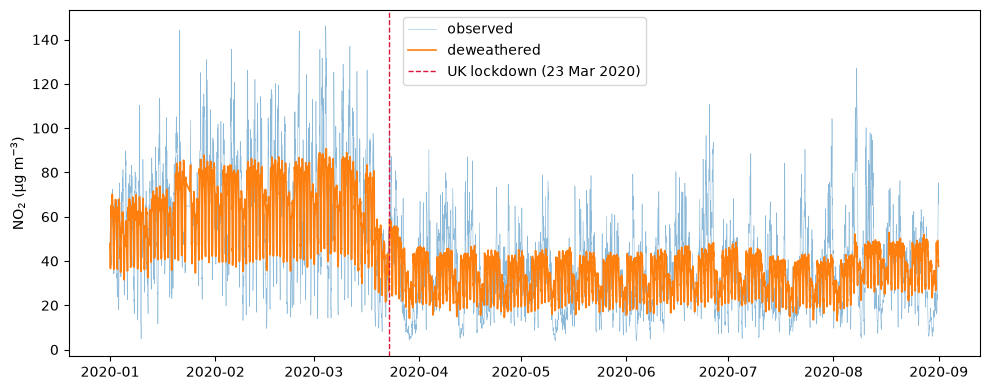

In [3]:
norm = nm.normalise(
    prep, model, covariates=PREDICTORS, variables_resample=MET_VARS,
    n_samples=100, seed=SEED, n_cores=4, verbose=False,
)
norm = norm.reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(norm["date"], norm["observed"], lw=0.4, alpha=0.5, label="observed")
ax.plot(norm["date"], norm["normalised"], lw=1.2, label="deweathered")
ax.axvline(x=norm["date"].iloc[0].replace(month=3, day=23), color="crimson", ls="--", lw=1,
           label="UK lockdown (23 Mar 2020)")
ax.set_ylabel("NO$_2$ (µg m$^{-3}$)")
ax.legend()
plt.tight_layout()

## 3. Adaptive convergence: how many samples are enough?

`nm.normalise_auto` runs the resampling in batches and stops automatically.
The paper introduces the **series criterion** (default): stop when the 95th
percentile of the per-date relative standard error of the cumulative mean
falls below 3%. The legacy **global criterion** watches the batch-to-batch
change of the global mean instead, which weakens as sampling proceeds.

In [4]:
histories = {}
for metric in ("series", "global"):
    r = nm.normalise_auto(
        prep, model, covariates=PREDICTORS, variables_resample=MET_VARS,
        convergence_metric=metric, batch_size=10, max_samples=300,
        seed=SEED, verbose=False, return_history=True, n_cores=4,
    )
    histories[metric] = (r["best_n"], r["history"])
    print(f"{metric:>6}: stopped at n = {r['best_n']}")

/tmp/slurm.17733969/ipykernel_1702546/2357194107.py:3: UserWarning: normalise_auto reached max_samples=300 without strict convergence.
  r = nm.normalise_auto(


series: stopped at n = 300


global: stopped at n = 60


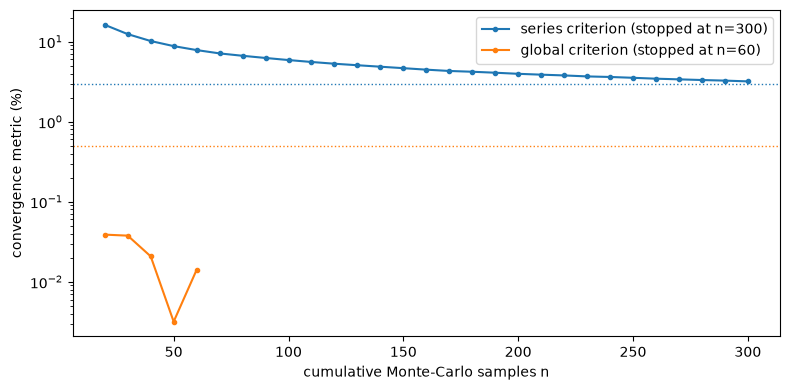

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for metric, tol, colour in [("series", 0.03, "tab:blue"), ("global", 0.005, "tab:orange")]:
    best_n, h = histories[metric]
    ax.plot(h["n"], h["metric"] * 100, marker="o", ms=3, color=colour,
            label=f"{metric} criterion (stopped at n={best_n})")
    ax.axhline(tol * 100, color=colour, ls=":", lw=1)
ax.set_yscale("log")
ax.set_xlabel("cumulative Monte-Carlo samples n")
ax.set_ylabel("convergence metric (%)")
ax.legend()
plt.tight_layout()

The series criterion tracks a CLT distance-to-limit measure — it declines
smoothly as $1/\sqrt{n}$ and stops once the *whole deweathered series* is
Monte-Carlo-converged, whereas the global criterion can stop early while
individual timestamps still carry sampling noise.